# Comparación de modelos — recepciones y yardas

## Qué responde este notebook

¿Qué familia de modelo predice mejor `receptions` y `receiving_yards`? Compiten Baseline (el
promedio del propio jugador), Ridge, RandomForest, XGBoost y HistGradientBoosting, con la tabla, las
particiones y la política de métricas de
[`4.1_preparacion_y_metricas.ipynb`](4.1_preparacion_y_metricas.ipynb): cada familia elige sus
hiperparámetros y el ganador se elige por **RMSE en validación**; la prueba se muestra pero no
decide. Los dos resultados van juntos porque dependen de las mismas variables;
`receiving_tds` va aparte en [`4.3_modelos_touchdowns.ipynb`](4.3_modelos_touchdowns.ipynb) porque
es un conteo con mayoría de ceros. Las variables se definen en el
[glosario](../../../docs/data/GLOSARIO_VARIABLES.md).

Además del ganador se revisa por qué gana, dónde se equivoca más y si conviene entrenar solo con las
semanas en que el receptor tuvo algún pase dirigido.

In [1]:
import sys
sys.path.insert(0, "../src")
import data, features, modeling, experimentos

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 160)
sns.set_style("whitegrid")
AZUL, NARANJA, VERDE, GRIS, GRIS_CLARO = "#2a78d6", "#eb6834", "#1baf7a", "#888780", "#c3c2b7"

wr = features.construir_tabla_modelado(range(2016, 2026))
features_arbol = features.columnas_por_modelo("arbol")
features_ridge = features.columnas_por_modelo("ridge")
train_mask, val_mask, test_mask = experimentos.dividir_temporal(
    wr, range(2016, 2022), [2022, 2023], [2024, 2025]
)
print(f"train: {train_mask.sum()}, val: {val_mask.sum()}, test: {test_mask.sum()}")

def tabla_comparacion(resultados, resumen, target):
    columnas = ["val_rmse", "val_r2_oos", "val_mae", "val_sesgo", "val_pendiente_calibracion"]
    if "val_deviance_poisson" in resumen.columns:
        columnas.append("val_deviance_poisson")
    columnas += ["test_rmse", "test_r2_oos", "test_mae"]
    tabla = resumen[columnas].copy()
    tabla.insert(5, "val_spearman_semanal", [
        experimentos.spearman_semanal(wr[val_mask], wr.loc[val_mask, target], resultados[n]["pred"][val_mask])
        for n in tabla.index
    ])
    return tabla.astype(float)

train: 13795, val: 4863, test: 4952


## 1. Por qué escalar Ridge

Los notebooks originales de `_reference/` solo usaban XGBoost. Ridge sí compite aquí, y antes
conviene escalar sus variables: Ridge penaliza los coeficientes por su tamaño, y en entrenamiento `draft_pick`
va de 3 a 473 mientras `wopr_last5_avg` va de 0 a cerca de 1. Sin escalar, la penalización efectiva de cada
variable depende de su rango y no de cuánto ayuda a predecir. Se prueba con `receiving_yards`:

In [2]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X_ridge = pd.get_dummies(wr[features_ridge], dummy_na=True)
y = wr["receiving_yards"]

sin_escalar = Pipeline([("imputar", SimpleImputer(strategy="median")), ("modelo", Ridge(alpha=1.0))])
sin_escalar.fit(X_ridge[train_mask], y[train_mask])
con_escalar = Pipeline([("imputar", SimpleImputer(strategy="median")),
                        ("escalar", StandardScaler()), ("modelo", Ridge(alpha=1.0))])
con_escalar.fit(X_ridge[train_mask], y[train_mask])

for nombre, pipe in (("sin escalar", sin_escalar), ("con escalar", con_escalar)):
    m = modeling.metricas(y[val_mask], pipe.predict(X_ridge[val_mask]))
    print(f"RMSE de validacion, receiving_yards, {nombre}: {m['rmse']:.3f}")

coefs = pd.DataFrame({
    "sin_escalar": sin_escalar.named_steps["modelo"].coef_,
    "con_escalar": con_escalar.named_steps["modelo"].coef_,
}, index=X_ridge.columns)
print()
print(coefs.loc[["draft_pick", "wopr_last5_avg"]].round(4))

RMSE de validacion, receiving_yards, sin escalar: 29.819
RMSE de validacion, receiving_yards, con escalar: 29.819

                sin_escalar  con_escalar
draft_pick          -0.0069      -1.2517
wopr_last5_avg      -4.2889      -1.2746


**Lectura.** Escalar casi no cambia el error (RMSE de 29.819 sin escalar y con escalar):
para predecir, Ridge compensa la escala. Lo que cambia es la lectura de los coeficientes. Sin escalar,
`draft_pick` pesa −0.0069 y `wopr_last5_avg` −4.289, como si `wopr` importara 600 veces más;
escalados quedan en el mismo orden (−1.252 y −1.275). Escalar es indispensable para interpretar el
modelo lineal, y el resto del notebook usa la versión escalada.

## 2. La competencia — `receiving_yards`

Tabla ordenada por RMSE de validación. `r2_oos` es la R² contra la media de entrenamiento; sesgo y
pendiente dicen si las predicciones están en la escala correcta (ideal: 0 y 1); Spearman semanal
mide si ordena bien a los receptores de cada semana.

In [3]:
resultados_yardas, resumen_yardas = experimentos.entrenar_y_evaluar(
    wr, "receiving_yards", features_arbol, features_ridge, train_mask, val_mask, test_mask
)
tabla_comparacion(resultados_yardas, resumen_yardas, "receiving_yards").round(3)

,val_rmse,val_r2_oos,val_mae,val_sesgo,val_pendiente_calibracion,val_spearman_semanal,test_rmse,test_r2_oos,test_mae
RandomForest,29.523,0.365,22.043,1.632,1.071,0.644,27.950,0.374,20.739
XGBoost,29.572,0.362,22.005,1.573,1.071,0.643,27.914,0.375,20.552
HistGradientBoosting,29.721,0.356,22.238,1.841,1.048,0.638,28.099,0.367,20.757
Ridge,29.818,0.352,22.352,1.992,1.058,0.634,28.286,0.359,20.306
Baseline,31.401,0.281,22.585,0.991,0.750,0.602,29.876,0.284,21.295


## 3. La competencia — `receptions`

Misma comparación. Como `receptions` también es un conteo, se agrega su deviance de Poisson en
validación como referencia; la que decide sigue siendo el RMSE.

In [4]:
resultados_recepciones, resumen_recepciones = experimentos.entrenar_y_evaluar(
    wr, "receptions", features_arbol, features_ridge, train_mask, val_mask, test_mask
)
tabla_comparacion(resultados_recepciones, resumen_recepciones, "receptions").round(3)

,val_rmse,val_r2_oos,val_mae,val_sesgo,val_pendiente_calibracion,val_spearman_semanal,val_deviance_poisson,test_rmse,test_r2_oos,test_mae
XGBoost,1.929,0.438,1.449,0.097,1.049,0.681,1.444,1.826,0.458,1.364
RandomForest,1.930,0.437,1.453,0.090,1.053,0.676,1.455,1.830,0.456,1.378
HistGradientBoosting,1.938,0.433,1.454,0.116,1.027,0.682,1.454,1.844,0.447,1.380
Ridge,1.949,0.426,1.477,0.136,1.040,0.669,1.499,1.851,0.443,1.365
Baseline,2.043,0.370,1.505,0.077,0.787,0.647,2.476,1.941,0.388,1.420


### Empates: ¿la diferencia entre los primeros lugares es real?

Se aplica la regla de empates de [`4.1_preparacion_y_metricas.ipynb`](4.1_preparacion_y_metricas.ipynb):
si el intervalo de 95% de la diferencia, por bootstrap de semanas completas, incluye cero, es un empate
y se elige XGBoost.

In [5]:
elegido = {}
for target, resultados, resumen in (("receiving_yards", resultados_yardas, resumen_yardas),
                                    ("receptions", resultados_recepciones, resumen_recepciones)):
    criterio = modeling.METRICA_PRINCIPAL[target]
    primero = resumen.index[0]
    if primero == "XGBoost":
        elegido[target] = "XGBoost"
        print(f"{target}: XGBoost queda primero en {criterio} de validacion")
        continue
    comparacion = experimentos.diferencia_bootstrap(
        wr[val_mask], wr.loc[val_mask, target],
        resultados[primero]["pred"][val_mask], resultados["XGBoost"]["pred"][val_mask], criterio,
    )
    elegido[target] = "XGBoost" if comparacion["empate"] else primero
    print(f"{target}: {primero} menos XGBoost en {criterio} de validacion = {comparacion['diferencia']:+.4f} "
          f"(IC 95%: {comparacion['ic_inferior']:+.4f} a {comparacion['ic_superior']:+.4f}) -> "
          f"{'empate' if comparacion['empate'] else 'diferencia real'}; se elige {elegido[target]}")

receiving_yards: RandomForest menos XGBoost en rmse de validacion = -0.0487 (IC 95%: -0.1306 a +0.0336) -> empate; se elige XGBoost
receptions: XGBoost queda primero en rmse de validacion


In [6]:
for target, resultados in (("receiving_yards", resultados_yardas), ("receptions", resultados_recepciones)):
    cumple, detalle = experimentos.cumple_requisitos(target, resultados[elegido[target]]["val"])
    print(f"{target}: {elegido[target]} | requisitos en validacion: {'cumple' if cumple else 'NO cumple'}")
    for chequeo, ok in detalle.items():
        print(f"   {'ok ' if ok else 'NO '} {chequeo}")

receiving_yards: XGBoost | requisitos en validacion: cumple
   ok  R2 fuera de muestra > 0 (validacion)
   ok  sesgo adicional al de la media de entrenamiento <= 5% de la media (validacion)
   ok  pendiente de calibracion entre 0.9 y 1.1 (validacion)
receptions: XGBoost | requisitos en validacion: cumple
   ok  R2 fuera de muestra > 0 (validacion)
   ok  sesgo adicional al de la media de entrenamiento <= 5% de la media (validacion)
   ok  pendiente de calibracion entre 0.9 y 1.1 (validacion)


**Lectura.** En yardas, los cuatro modelos aprendidos superan al baseline con margen claro: RMSE de
validación entre 29.52 y 29.82 contra 31.40, y R² fuera de muestra de 0.35 a 0.37 contra 0.28.
Entre RandomForest y XGBoost la diferencia es de 0.049 yardas y su intervalo va de −0.131 a +0.034,
así que es un empate y se elige XGBoost. En recepciones XGBoost queda primero (RMSE de 1.929 contra
1.930 de RandomForest, también prácticamente empatados) y todos superan al baseline (2.043).

Los dos elegidos cumplen los requisitos en validación, con un sesgo positivo pequeño (+1.57 yardas y
+0.10 recepciones) y pendientes de 1.07 y 1.05. El baseline tiene pendiente de 0.75 y 0.79: sus
predicciones son demasiado extremas, porque el promedio de pocas semanas exagera los altibajos. Los
elegidos también ordenan mejor a los receptores de cada semana (Spearman de 0.64 y 0.68 contra 0.60 y
0.65 del baseline). En prueba mantienen el nivel: R² fuera de muestra de 0.3754 en yardas y 0.4585 en
recepciones.

## 4. ¿Por qué gana el ganador?

Primera mirada con la importancia nativa del ganador de `receiving_yards` (cuánto mejora el modelo
cada vez que usa la variable). La lectura completa, con SHAP y casos reales, está en
[`5.3_explicabilidad_y_casos.ipynb`](5.3_explicabilidad_y_casos.ipynb).

In [7]:
ganador_nombre_yardas = elegido["receiving_yards"]
ganador_yardas = resultados_yardas[ganador_nombre_yardas]["modelo"]
print("Modelo elegido para receiving_yards:", ganador_nombre_yardas)

if hasattr(ganador_yardas, "feature_importances_"):
    importancia = pd.Series(ganador_yardas.feature_importances_, index=features_arbol).sort_values(ascending=False)
    print(importancia.head(10).round(4))
else:
    print("El ganador no expone feature_importances_ nativa (probablemente Ridge) -- ver coeficientes arriba.")

Modelo elegido para receiving_yards: XGBoost
fantasy_points_ppr_last5_avg       0.1750
wopr_last5_avg                     0.1380
target_share_last5_avg             0.1194
receiving_yards_career_avg         0.1164
receptions_career_avg              0.0534
depth_team                         0.0462
receiving_yards_season_avg         0.0398
targets_last5_avg                  0.0361
wopr_last3_avg                     0.0350
receiving_first_downs_last5_avg    0.0293
dtype: float32


**Lectura.** Las variables que más usa XGBoost en yardas son de uso reciente y de producción:
`fantasy_points_ppr_last5_avg` (0.18), `wopr_last5_avg` (0.14), `target_share_last5_avg` (0.12)
y `receiving_yards_career_avg` (0.12), en línea con `3.2_seleccion_features.ipynb`, donde la
participación reciente dominaba. `depth_team` queda en sexto lugar (0.046). Esta importancia mide
cuánto se apoya el modelo en cada variable, no su efecto causal; la lectura con SHAP está en
`5.3_explicabilidad_y_casos.ipynb`.

## 5. Error por segmento de uso — ¿dónde se equivoca más?

Se parte a los receptores en cuartiles de uso reciente (`target_share_last5_avg`) y en cada cuartil
se compara el promedio real contra el predicho, en el conjunto de prueba. Las filas sin historia de
uso (la primera aparición de un jugador) no tienen cuartil y quedan fuera.

In [8]:
test_df = wr[test_mask].copy()
test_df["pred"] = resultados_yardas[ganador_nombre_yardas]["pred"][test_mask]
test_df["error_abs"] = (test_df["pred"] - test_df["receiving_yards"]).abs()
test_df["cuartil_uso"] = pd.qcut(test_df["target_share_last5_avg"], 4, labels=["Q1 (bajo)", "Q2", "Q3", "Q4 (alto)"])

resumen_error = test_df.groupby("cuartil_uso", observed=True).agg(
    mae=("error_abs", "mean"), n=("error_abs", "size"),
    promedio_real=("receiving_yards", "mean"), promedio_pred=("pred", "mean"),
)
resumen_error

,mae,n,promedio_real,promedio_pred
cuartil_uso,,,,
Q1 (bajo),11.149809,1213,8.794724,10.462862
Q2,17.841216,1213,20.585326,22.181200
Q3,24.196228,1213,37.999176,39.165321
Q4 (alto),29.637842,1213,60.971146,61.005886


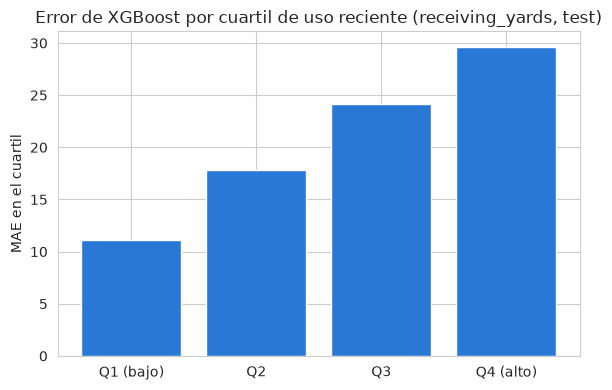

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(resumen_error.index.astype(str), resumen_error["mae"], color=AZUL)
ax.set_ylabel("MAE en el cuartil")
ax.set_title(f"Error de {ganador_nombre_yardas} por cuartil de uso reciente (receiving_yards, test)")
plt.tight_layout()
plt.show()

**Lectura.** El error absoluto crece con el uso (11.1, 17.8, 24.2 y 29.6 yardas) porque los
receptores de más uso producen más yardas que fallar; en proporción a lo que producen, el error es
menor entre los de mucho uso. Lo que dice si el modelo está sesgado es comparar promedios. En el
cuartil de más uso predice 61.0 contra 61.0 reales, sin sesgo. En los otros tres se pasa entre 1.2 y
1.7 yardas (10.5 contra 8.8, 22.2 contra 20.6 y 39.2 contra 38.0). Es un sesgo pequeño frente al
error de un partido y va en una sola dirección: el modelo se pasa un poco con los receptores de poco y
mediano uso.

## 6. ¿Conviene entrenar solo con las semanas activas?

Una semana «activa» es una en que el receptor tuvo al menos un pase dirigido (`targets > 0`). La
comparación justa evalúa ambas versiones sobre las mismas semanas activas de **validación**: si se
evaluara cada versión sobre su propia población, las semanas en cero (fáciles de predecir) harían
ver mejor a la que las incluye.

In [10]:
activos_mask = wr["targets"] > 0
val_activos_mask = val_mask & activos_mask

rmse_entrenado_con_todas = {
    nombre: modeling.metricas(wr["receiving_yards"][val_activos_mask], salida["pred"][val_activos_mask])["rmse"]
    for nombre, salida in resultados_yardas.items()
}
_, resumen_solo_activos = experimentos.entrenar_y_evaluar(
    wr, "receiving_yards", features_arbol, features_ridge,
    train_mask & activos_mask, val_activos_mask, test_mask & activos_mask,
)
pd.DataFrame({
    "entrenado con todas (RMSE en validacion activa)": rmse_entrenado_con_todas,
    "entrenado solo con activas (RMSE en validacion activa)": resumen_solo_activos["val_rmse"],
}).astype(float).round(3)

,entrenado con todas (RMSE en validacion activa),entrenado solo con activas (RMSE en validacion activa)
Baseline,33.016,33.061
HistGradientBoosting,31.196,31.292
RandomForest,30.987,31.129
Ridge,31.244,31.358
XGBoost,31.047,31.138


**Lectura.** Evaluando sobre las mismas semanas activas de validación, entrenar con todas las
semanas gana en los cinco modelos (XGBoost: 31.047 contra 31.138). Las semanas sin pases dirigidos
siguen aportando información del jugador y de su equipo. Se entrena con todas las semanas.

## Cierre

En recepciones y yardas, todas las familias aprendidas superan claramente al baseline y quedan
prácticamente empatadas entre sí. Se elige XGBoost en los dos: en recepciones porque queda primero en
RMSE de validación, y en yardas por la regla de empate. Ambos cumplen los requisitos en validación;
la revisión año por año está en `5.1_estabilidad_temporal.ipynb`, y sus hiperparámetros se afinan en
`4.4_ajuste_hiperparametros.ipynb`.

Anterior: [`4.1_preparacion_y_metricas.ipynb`](4.1_preparacion_y_metricas.ipynb) · Siguiente:
[`4.3_modelos_touchdowns.ipynb`](4.3_modelos_touchdowns.ipynb)